# 11 — BRICHOS reduces microglial inflammation via *state*, not *abundance*

Summary of the microglia inflammation analysis (scripts `10`, `10b`, `10c`).

**Question.** Having identified microglia-enriched spots from the deconvolution, does
BRICHOS reduce neuroinflammation — and if so, by recruiting *fewer* microglia or by
shifting the microglia that are there toward a less inflammatory phenotype?

**Data.** Full ST expression (`combined_samples.h5ad`, 25,671 × 19,465 raw counts) lives
on the remote analysis machine; deconvolution annotations (treatment / region / props)
were joined in by spot barcode. Analysis was run remotely (env `sc_py312`); this notebook
presents the exported figures and statistics.

**Design.** Microglia-enriched 'hotspots' = global *z*(prop_MYE:Microglia) > 1.5.
Per-spot signature scores: Homeostatic (P2ry12, Tmem119, Cx3cr1, Hexb…), DAM /
disease-associated (Trem2, Cst7, Itgax, Apoe, Cd68, Spp1…), Neuroinflammation, Complement.
DAM:homeostatic ratio = DAM − Homeostatic.

**Statistics.** WT (*n*=1 section) is descriptive only. The testable contrast is
**PBS (*n*=6) vs BRICHOS (*n*=3)**. Primary test = linear mixed model (spot-level, section
as random effect); section-level pseudobulk Mann-Whitney as sensitivity.


In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import Image, display
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)

# locate results/inflammation regardless of where the kernel starts
p = Path.cwd().resolve()
RES = None
for cand in [p, *p.parents]:
    if (cand / 'results' / 'inflammation').is_dir():
        RES = cand / 'results' / 'inflammation'; break
assert RES is not None, 'results/inflammation not found'
FIG, TAB = RES / 'figs', RES / 'tables'
print('results at', RES)
print(json.loads((RES / 'run_summary.json').read_text()))

results at /Users/chrislangseth/work/karolinska_institutet/projects/ST-BRICHOS/notebooks/results/inflammation
{'z_thresh': 1.5, 'n_spots': 25660, 'n_hotspots': 1644, 'hotspots_per_treatment': {'PBS': 1123, 'BRICHOS': 476, 'WT': 45}, 'signatures': {'Homeostatic': ['P2ry12', 'Tmem119', 'Cx3cr1', 'Hexb', 'Siglech', 'Selplg', 'Csf1r', 'Sall1', 'Gpr34', 'Olfml3', 'Serinc3', 'Cst3'], 'DAM': ['Trem2', 'Tyrobp', 'Cst7', 'Itgax', 'Apoe', 'Cd68', 'Lpl', 'Ctsb', 'Ctsd', 'Cd9', 'Spp1', 'Gpnmb', 'Lgals3', 'B2m', 'Fth1', 'Axl'], 'Neuroinflammation': ['Il1b', 'Tnf', 'Nfkbia', 'Ccl3', 'Ccl4', 'Ccl2', 'Cxcl10', 'Nlrp3', 'Il6', 'Tlr2', 'Ptgs2', 'Nfkb1', 'Rela', 'Il1a', 'Tnfaip3'], 'Complement': ['C1qa', 'C1qb', 'C1qc', 'C3', 'C4b', 'C1qbp', 'Cfh'], 'ReactiveAstro': ['Gfap', 'Vim', 'Serpina3n', 'C3', 'Lcn2', 'Cp', 'Steap4']}, 'de_ok': True}


## 1 · Core result — microglia state by treatment (in enriched spots)

Homeostatic identity is **restored** under BRICHOS (mixed-model p = 0.013) and the
DAM:homeostatic ratio **drops** (p = 0.056), while the DAM program itself is unchanged
(p = 0.40) — i.e. the shift is driven by recovering homeostatic markers, not by lowering
DAM. Microglia *abundance* does not change (fraction 0.151 vs 0.152).


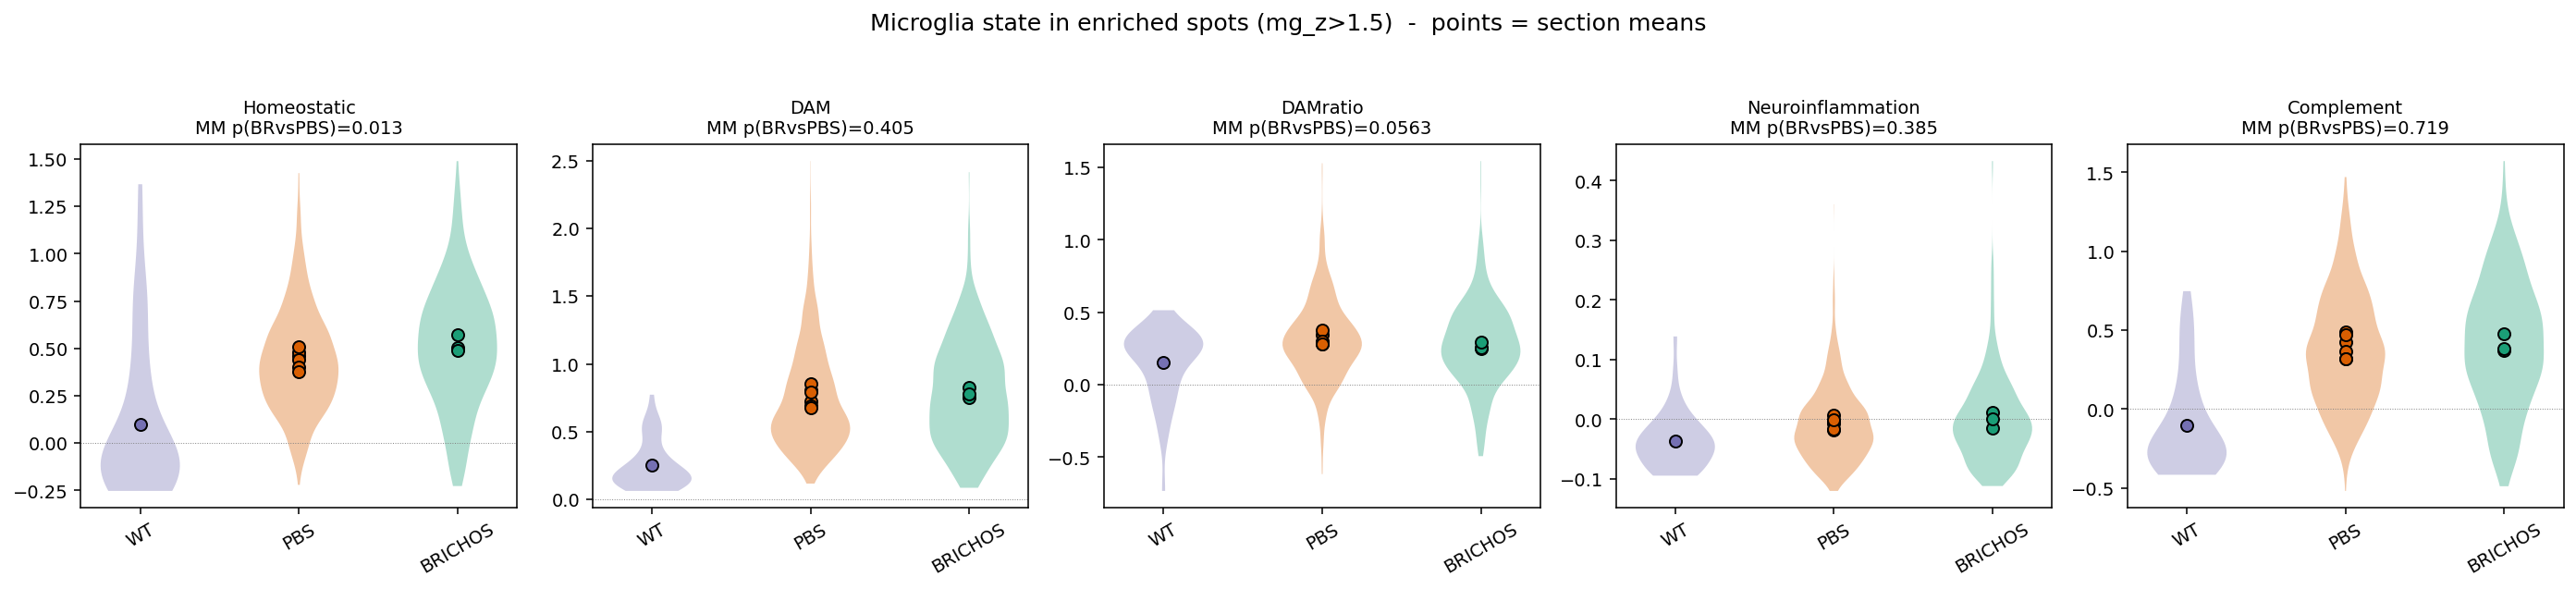

In [2]:
display(Image(str(FIG / 'inflam_state_by_treatment.png')))

In [3]:
mm = pd.read_csv(TAB / 'state_mixedmodel_pseudobulk.csv')
mm[['metric','mm_beta','mm_p','PBS_mean','BRICHOS_mean','delta','MWU_p','WT_mean']].round(4)

,metric,mm_beta,mm_p,PBS_mean,BRICHOS_mean,delta,MWU_p,WT_mean
0,sig_Homeostatic,0.0765,0.0130,0.4451,0.5209,0.0757,0.0952,0.1002
1,sig_DAM,0.0333,0.4049,0.7573,0.7868,0.0295,0.7143,0.2529
2,sig_Neuroinflammation,0.0057,0.3848,-0.0063,-0.0012,0.0052,0.3810,-0.0363
3,sig_Complement,0.0156,0.7190,0.3980,0.4114,0.0134,0.7143,-0.1032
4,sig_ReactiveAstro,-0.0236,0.3883,-0.0338,-0.0582,-0.0244,0.3810,-0.2515
5,sig_DAMratio,-0.0400,0.0563,0.3122,0.2659,-0.0463,0.1667,0.1527
6,mg_z,0.0745,0.1458,2.2928,2.3433,0.0505,0.2619,2.4552
7,prop_MYE:Microglia,NaN,NaN,0.1514,0.1525,0.0011,0.2619,0.1549


## 2 · Independent corroboration — GSEA (gene-ranking level)

Pre-ranked GSEA on the BRICHOS-vs-PBS pseudobulk DE ranking: the **Homeostatic** program
is enriched *up* in BRICHOS (NES +2.06) and the **reactive-astrocyte** program *down*
(NES −1.81). No single gene passes FDR (n = 6 vs 3 is underpowered), so the signal is
programmatic rather than driven by a few genes.


In [4]:
pd.read_csv(TAB / 'gsea_prerank_inflammatory.csv').round(4)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Homeostatic,0.8020,2.0601,0.0000,0.0000,0.0000,9/11,16.39%,P2ry12;Cx3cr1;Hexb;Csf1r;Selplg;Siglech;Gpr34;...
1,prerank,ReactiveAstro,-0.8737,-1.8058,0.0000,0.0047,0.0114,3/5,9.92%,Cp;Vim;Gfap
2,prerank,DAM,0.5126,1.4580,0.0693,0.1358,0.1710,6/16,21.78%,Ctsd;Cd68;Tyrobp;Cd9;Itgax;Ctsb
3,prerank,Neuroinflammation,0.3488,0.9181,0.5969,0.7660,0.8320,5/11,24.24%,Tlr2;Il1a;Ccl3;Ccl4;Ptgs2
4,prerank,Complement,0.2460,0.5556,0.9701,0.9683,0.9670,1/7,9.38%,C1qb


## 3 · Sensitivity — not an abundance artifact, not a threshold artifact

Adjusting the mixed model for microglia fraction **strengthens** the DAM:homeostatic
reduction (significant at every threshold: p = 3e-6 / 0.022 / 0.033), and the direction
is stable across z > 1.0 / 1.5 / 2.0. The homeostatic increase survives adjustment;
DAM never differs.


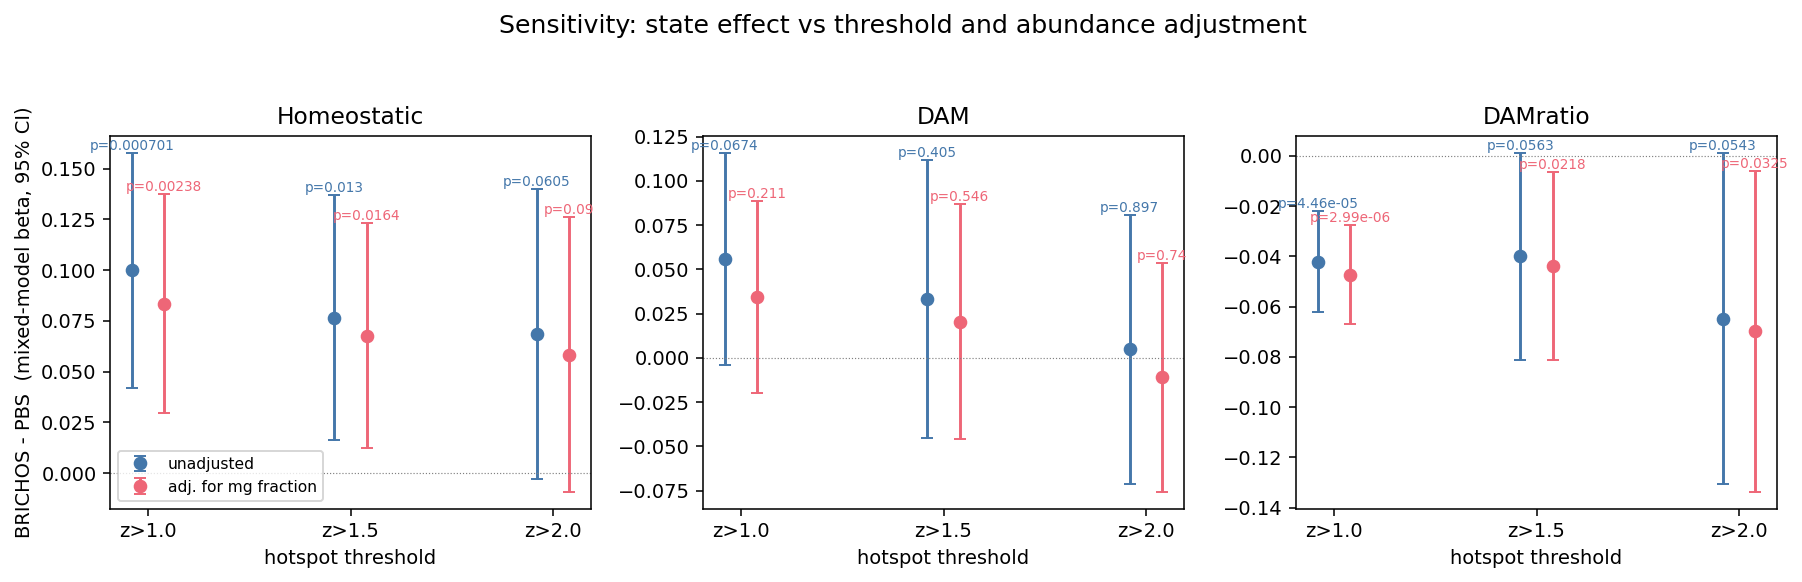

In [5]:
display(Image(str(FIG / 'inflam_sensitivity.png')))

In [6]:
s = pd.read_csv(TAB / 'sensitivity_threshold_adjust.csv')
s[['z','metric','adjusted','n_PBS','n_BRICHOS','beta','p','lo','hi']].round(4)

,z,metric,adjusted,n_PBS,n_BRICHOS,beta,p,lo,hi
0,1.0,sig_Homeostatic,False,2427,884,0.1000,0.0007,0.0422,0.1578
1,1.0,sig_Homeostatic,True,2427,884,0.0835,0.0024,0.0296,0.1374
2,1.0,sig_DAM,False,2427,884,0.0559,0.0674,-0.0040,0.1158
3,1.0,sig_DAM,True,2427,884,0.0345,0.2111,-0.0196,0.0886
4,1.0,sig_DAMratio,False,2427,884,-0.0421,0.0000,-0.0623,-0.0219
5,1.0,sig_DAMratio,True,2427,884,-0.0472,0.0000,-0.0671,-0.0274
6,1.5,sig_Homeostatic,False,1123,476,0.0765,0.0130,0.0161,0.1370
7,1.5,sig_Homeostatic,True,1123,476,0.0677,0.0164,0.0124,0.1230
8,1.5,sig_DAM,False,1123,476,0.0333,0.4049,-0.0451,0.1117
9,1.5,sig_DAM,True,1123,476,0.0205,0.5458,-0.0460,0.0869


## 4 · Deconvolution-weighted signatures + region-stratified test

**(A)** Weighting *every* spot by its microglia fraction (no hard threshold) reproduces the
DAM:homeostatic reduction at section level (Δ = −0.026, MWU p = 0.024) — the result does
not depend on how 'enriched' is defined.

**(B)** The treatment×region interaction is **not** significant (DAM:homeostatic LR p = 0.19),
so the shift is broadly global. Descriptively the largest reductions are in meninges and
olfactory areas, and 6/8 tested regions point the same way, but per-region tests are
underpowered — region-specificity is **not** statistically supported.


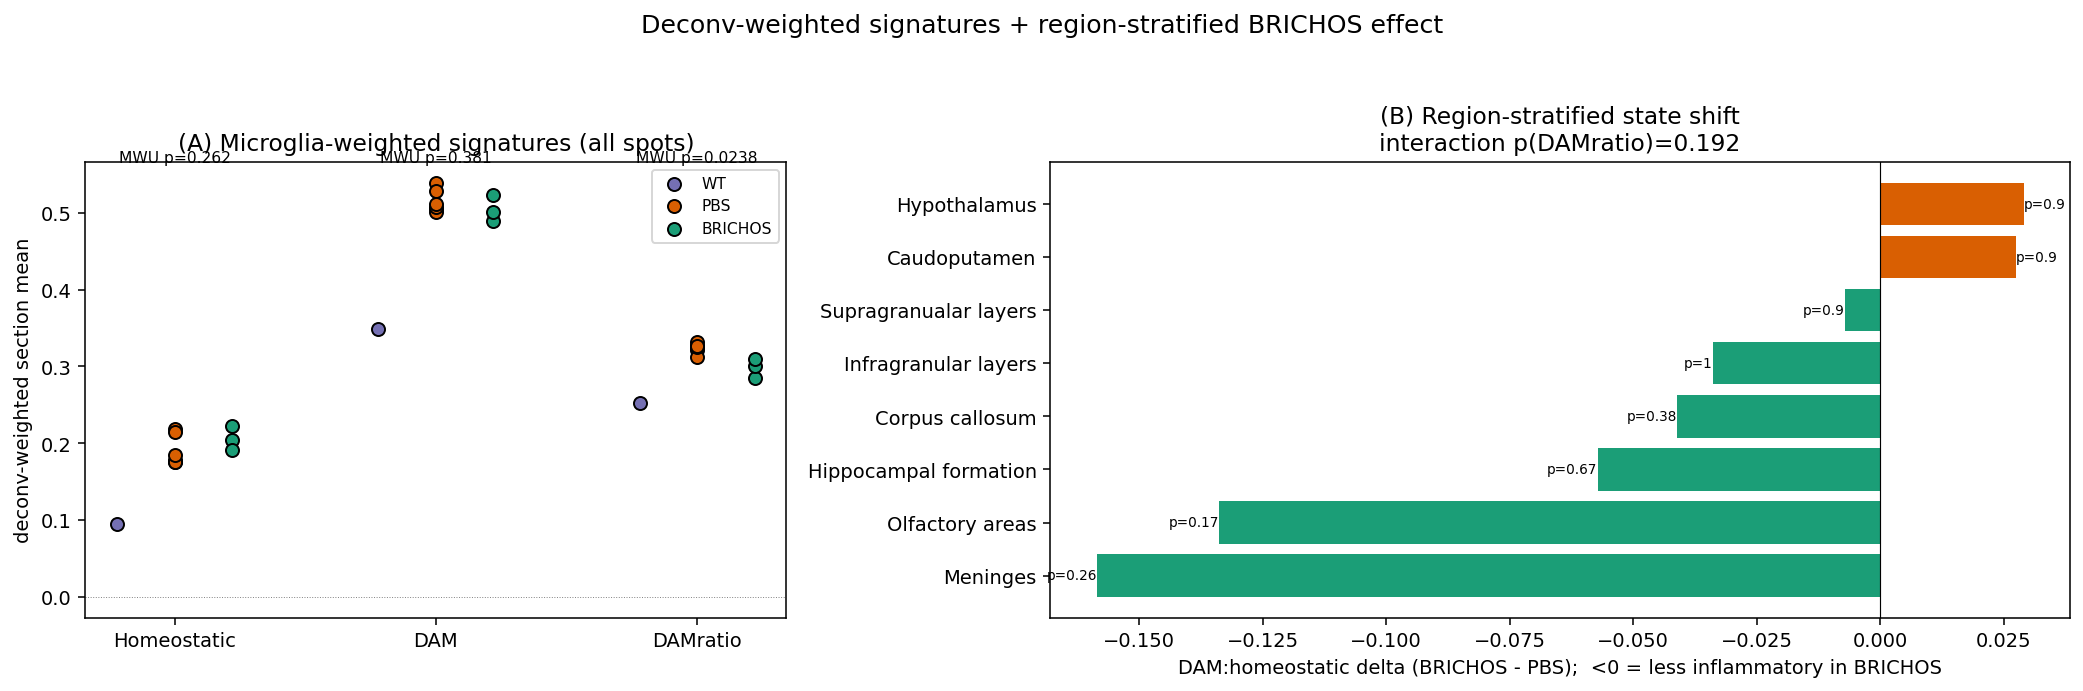

In [7]:
display(Image(str(FIG / 'inflam_weighted_regional.png')))

In [8]:
print('(A) deconv-weighted section-level summary:')
display(pd.read_csv(TAB / 'weighted_summary.csv').round(4))
print('(B) region-stratified DAM:homeostatic deltas:')
rr = pd.read_csv(TAB / 'region_stratified.csv')
rr[rr.metric == 'sig_DAMratio'].sort_values('delta').round(4)

(A) deconv-weighted section-level summary:


,metric,PBS_mean,BRICHOS_mean,delta,MWU_p,WT_mean
0,sig_Homeostatic,0.1914,0.2059,0.0145,0.2619,0.0952
1,sig_DAM,0.5154,0.5041,-0.0113,0.3810,0.3482
2,sig_DAMratio,0.3240,0.2982,-0.0258,0.0238,0.2530


(B) region-stratified DAM:homeostatic deltas:


,region,metric,PBS_mean,BRICHOS_mean,delta,n_PBS,n_BRICHOS,MWU_p
17,Meninges,sig_DAMratio,0.3488,0.1901,-0.1587,6,3,0.2619
20,Olfactory areas,sig_DAMratio,0.2656,0.1317,-0.1339,6,3,0.1667
8,Hippocampal formation,sig_DAMratio,0.2560,0.1988,-0.0572,2,1,0.6667
5,Corpus callosum,sig_DAMratio,0.3693,0.3282,-0.0411,6,3,0.3810
14,Infragranular layers,sig_DAMratio,0.4190,0.3851,-0.0339,6,3,1.0000
23,Supragranualar layers,sig_DAMratio,0.4710,0.4638,-0.0072,6,3,0.9048
2,Caudoputamen,sig_DAMratio,0.2254,0.2528,0.0274,6,3,0.9048
11,Hypothalamus,sig_DAMratio,0.2457,0.2748,0.0291,6,3,0.9048


## 5 · Spatial and DE views

DAM:homeostatic ratio across all sections, the regional bar view, and the hotspot
pseudobulk volcano (no gene survives FDR — consistent with a program-level effect).


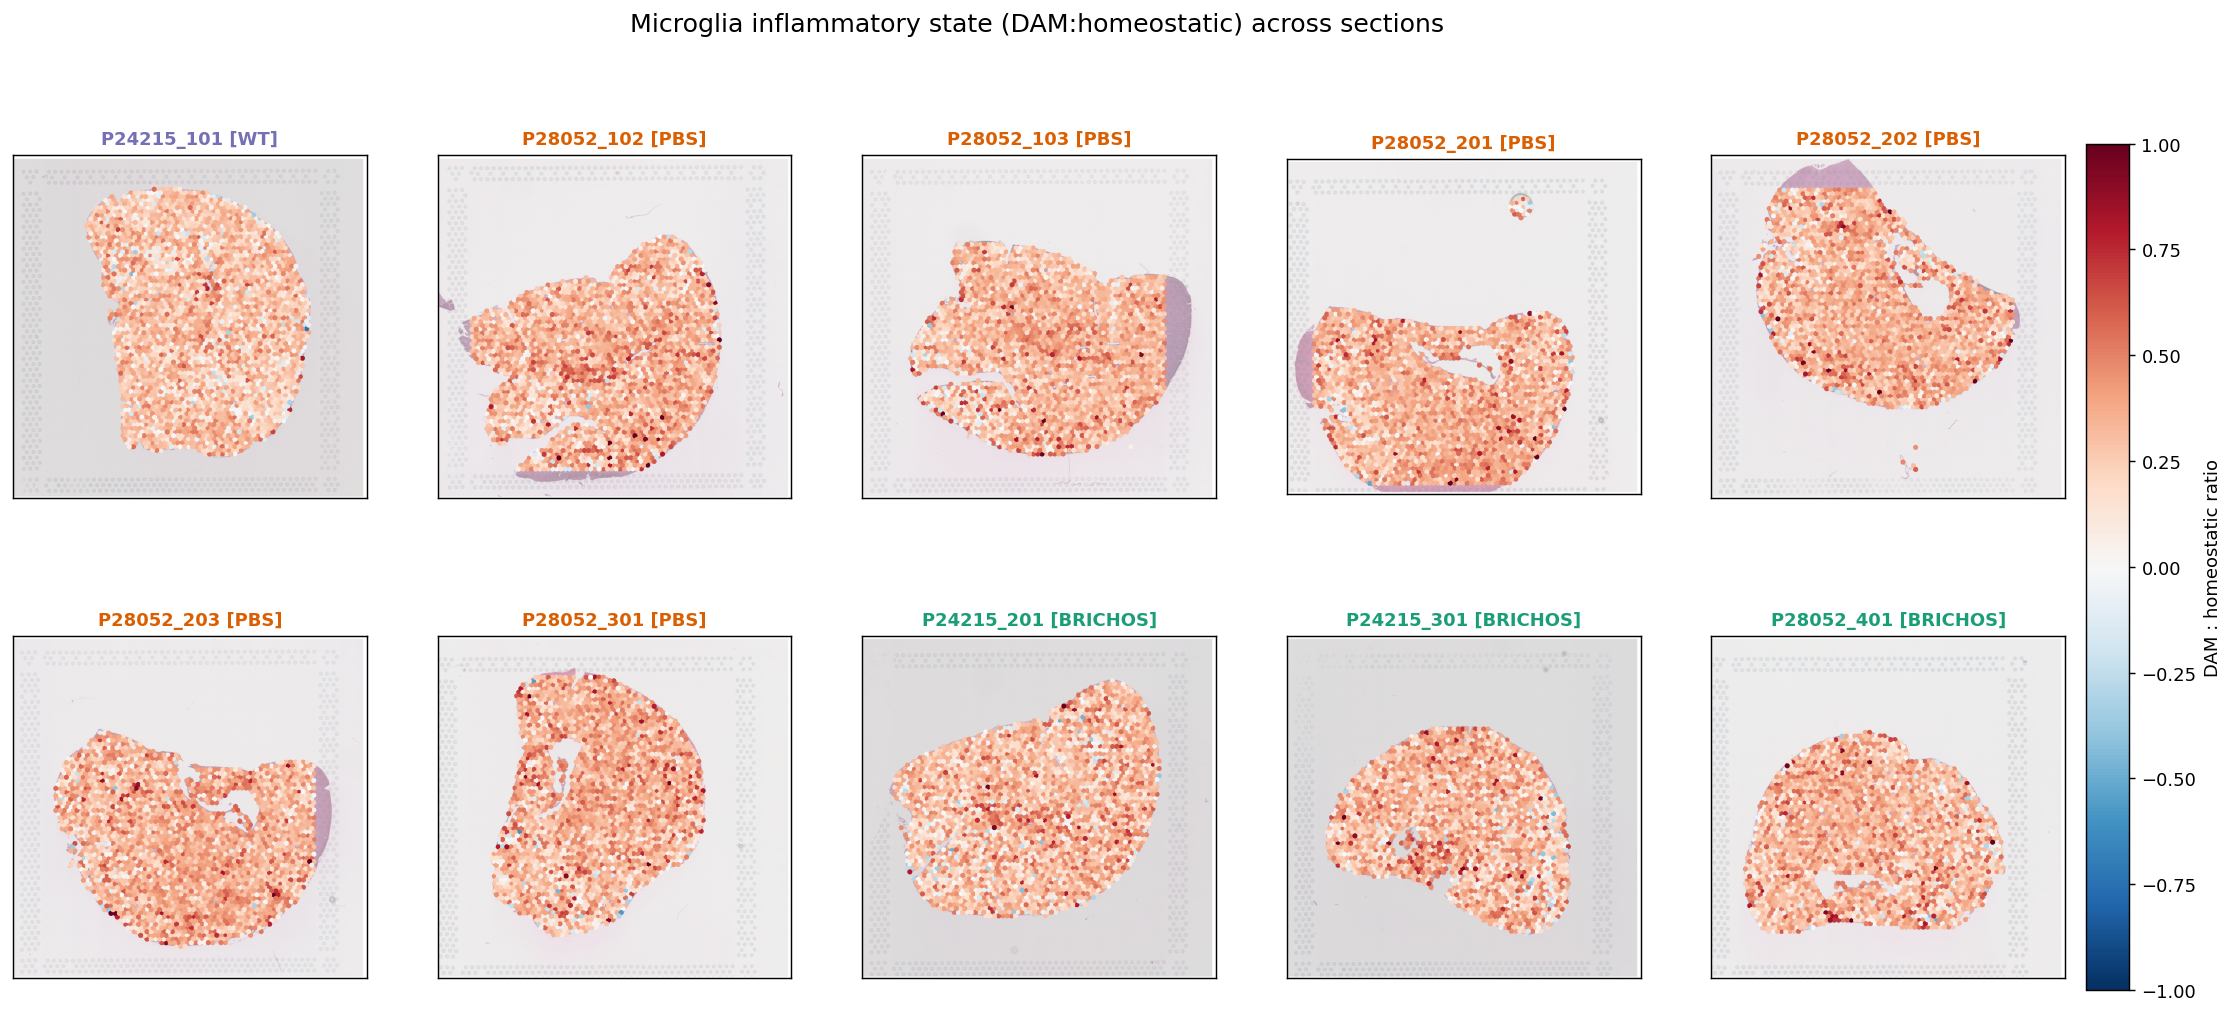

In [9]:
display(Image(str(FIG / 'inflam_spatial_DAMratio_grid.png')))

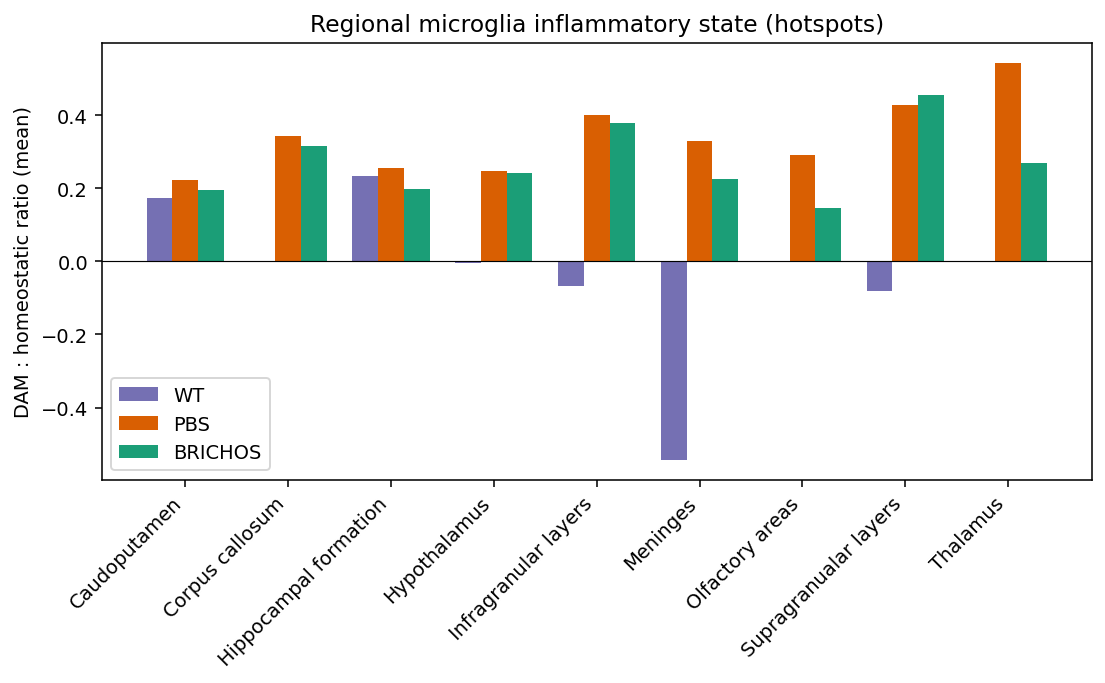

In [10]:
display(Image(str(FIG / 'inflam_regional_DAMratio.png')))

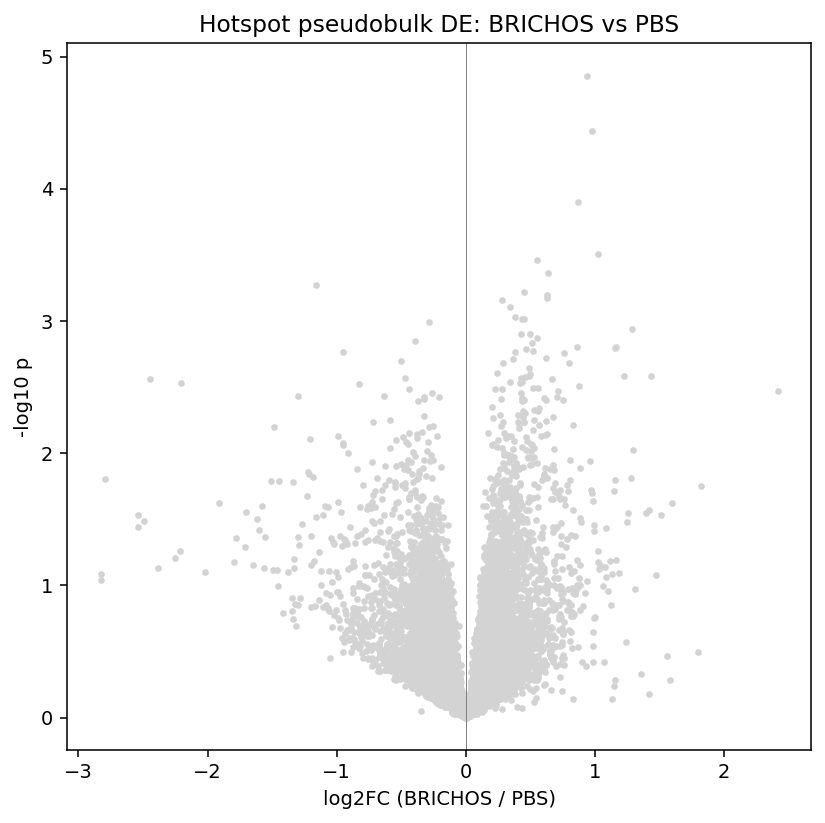

In [11]:
display(Image(str(FIG / 'inflam_de_volcano.png')))

## Conclusions

- **BRICHOS does not change microglial abundance** (fraction 0.151 vs 0.152, ns).
- **It shifts microglia toward a homeostatic state**: homeostatic signature up
  (mixed-model p = 0.013), DAM:homeostatic ratio down (p = 0.056), DAM unchanged.
- The effect is **abundance-independent** (strengthens after adjustment), **threshold-stable**,
  reproduced **threshold-free** by deconv-weighting (p = 0.024), and corroborated by **GSEA**.
- The shift is **broadly global**, not statistically region-specific at current power.

**Ceiling.** *n* = 6 PBS vs 3 BRICHOS, WT *n* = 1, and spot-level (not single-cell)
resolution — the signal is at the program level, which is why signatures/GSEA show it and
single-gene DE does not. A single-cell / snRNA validation of the homeostatic-restoration
signature would be the natural next step (new data).
